# BidGuard AI — Feature Engineering & ML Preparation

## Phase 03: Feature Engineering

This notebook prepares the BidGuard AI risk dataset for machine learning.

### Objectives
- Load and inspect the risk dataset
- Identify the target variable
- Analyze feature types
- Detect potential data leakage
- Select valid ML features
- Prepare the dataset for model training

### Target Variable
`risk_level`

### Dataset
`data/processed/risk_dataset.csv`

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/risk_dataset.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (4748, 21)

Columns:
['tender_id', 'bidder_id', 'total_requirements', 'mandatory_requirements', 'compliant_count', 'partially_compliant_count', 'non_compliant_count', 'insufficient_evidence_count', 'compliance_percentage', 'missing_document_count', 'expired_document_count', 'invalid_document_count', 'inconsistency_count', 'evidence_confidence_average', 'mandatory_failure_count', 'financial_requirement_failure', 'experience_requirement_failure', 'registration_requirement_failure', 'authorization_requirement_failure', 'document_quality_score', 'risk_level']


In [2]:
print(df.head())

    tender_id   bidder_id  total_requirements  mandatory_requirements  \
0  TND-000001  BID-001090                  24                      16   
1  TND-000001  BID-000942                  24                      16   
2  TND-000001  BID-001691                  24                      16   
3  TND-000001  BID-001424                  24                      16   
4  TND-000001  BID-001516                  24                      16   

   compliant_count  partially_compliant_count  non_compliant_count  \
0               12                          3                    1   
1               16                          4                    1   
2                6                          3                    1   
3               18                          0                    2   
4               21                          2                    1   

   insufficient_evidence_count  compliance_percentage  missing_document_count  \
0                            8                  50.00      

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4748 entries, 0 to 4747
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   tender_id                          4748 non-null   str    
 1   bidder_id                          4748 non-null   str    
 2   total_requirements                 4748 non-null   int64  
 3   mandatory_requirements             4748 non-null   int64  
 4   compliant_count                    4748 non-null   int64  
 5   partially_compliant_count          4748 non-null   int64  
 6   non_compliant_count                4748 non-null   int64  
 7   insufficient_evidence_count        4748 non-null   int64  
 8   compliance_percentage              4748 non-null   float64
 9   missing_document_count             4748 non-null   int64  
 10  expired_document_count             4748 non-null   int64  
 11  invalid_document_count             4748 non-null   int64  
 12  inc

In [4]:
# Target variable analysis

print("Target variable:", "risk_level")
print("\nRisk level distribution:")
print(df["risk_level"].value_counts())

print("\nRisk level percentage:")
print(df["risk_level"].value_counts(normalize=True).mul(100).round(2))

Target variable: risk_level

Risk level distribution:
risk_level
LOW       1899
MEDIUM    1662
HIGH      1187
Name: count, dtype: int64

Risk level percentage:
risk_level
LOW       40.0
MEDIUM    35.0
HIGH      25.0
Name: proportion, dtype: float64


In [5]:
print("Target dtype:", df["risk_level"].dtype)

print("\nUnique target classes:")
print(df["risk_level"].unique())

Target dtype: str

Unique target classes:
<StringArray>
['MEDIUM', 'LOW', 'HIGH']
Length: 3, dtype: str


In [6]:
# Features that may have a direct relationship with the target
potential_leakage_features = [
    "compliant_count",
    "partially_compliant_count",
    "non_compliant_count",
    "insufficient_evidence_count",
    "compliance_percentage",
    "missing_document_count",
    "expired_document_count",
    "invalid_document_count",
    "inconsistency_count",
    "mandatory_failure_count",
    "financial_requirement_failure",
    "experience_requirement_failure",
    "registration_requirement_failure",
    "authorization_requirement_failure"
]

print("Potential leakage / target-derived features:\n")

for feature in potential_leakage_features:
    print("-", feature)

Potential leakage / target-derived features:

- compliant_count
- partially_compliant_count
- non_compliant_count
- insufficient_evidence_count
- compliance_percentage
- missing_document_count
- expired_document_count
- invalid_document_count
- inconsistency_count
- mandatory_failure_count
- financial_requirement_failure
- experience_requirement_failure
- registration_requirement_failure
- authorization_requirement_failure


In [7]:
# Leakage audit: compare feature behavior across risk levels

leakage_audit = (
    df.groupby("risk_level")[potential_leakage_features]
      .mean()
      .round(3)
)

print("Mean feature values by risk level:")
print(leakage_audit)

Mean feature values by risk level:
            compliant_count  partially_compliant_count  non_compliant_count  \
risk_level                                                                    
HIGH                  3.860                      1.081                5.131   
LOW                  21.669                      1.187                1.424   
MEDIUM               13.700                      4.225                1.731   

            insufficient_evidence_count  compliance_percentage  \
risk_level                                                       
HIGH                             16.039                 14.847   
LOW                               1.754                 83.178   
MEDIUM                            6.379                 52.671   

            missing_document_count  expired_document_count  \
risk_level                                                   
HIGH                         0.503                   0.596   
LOW                          0.085                  

In [8]:
# Numerical correlation with the target encoded as ordinal risk

risk_mapping = {
    "LOW": 0,
    "MEDIUM": 1,
    "HIGH": 2
}

df["risk_level_encoded"] = df["risk_level"].map(risk_mapping)

correlation_with_risk = (
    df.select_dtypes(include=np.number)
      .corr()["risk_level_encoded"]
      .drop("risk_level_encoded")
      .sort_values(key=abs, ascending=False)
)

print("Feature correlation with risk level:")
print(correlation_with_risk.round(3))

Feature correlation with risk level:
compliance_percentage               -0.926
compliant_count                     -0.905
mandatory_failure_count              0.889
insufficient_evidence_count          0.808
evidence_confidence_average         -0.544
non_compliant_count                  0.416
inconsistency_count                  0.278
registration_requirement_failure     0.278
invalid_document_count               0.259
expired_document_count               0.255
missing_document_count               0.204
financial_requirement_failure        0.169
authorization_requirement_failure    0.142
experience_requirement_failure       0.123
partially_compliant_count            0.047
document_quality_score              -0.018
total_requirements                   0.011
mandatory_requirements               0.001
Name: risk_level_encoded, dtype: float64


In [9]:
# Feature grouping for leakage analysis

identifier_features = [
    "tender_id",
    "bidder_id"
]

structural_features = [
    "total_requirements",
    "mandatory_requirements"
]

compliance_derived_features = [
    "compliant_count",
    "partially_compliant_count",
    "non_compliant_count",
    "insufficient_evidence_count",
    "compliance_percentage",
    "missing_document_count",
    "expired_document_count",
    "invalid_document_count",
    "inconsistency_count",
    "mandatory_failure_count",
    "financial_requirement_failure",
    "experience_requirement_failure",
    "registration_requirement_failure",
    "authorization_requirement_failure"
]

quality_features = [
    "evidence_confidence_average",
    "document_quality_score"
]

target = "risk_level"

print("Identifier features:", identifier_features)
print("\nStructural features:", structural_features)
print("\nCompliance-derived features:", compliance_derived_features)
print("\nQuality features:", quality_features)
print("\nTarget:", target)

Identifier features: ['tender_id', 'bidder_id']

Structural features: ['total_requirements', 'mandatory_requirements']

Compliance-derived features: ['compliant_count', 'partially_compliant_count', 'non_compliant_count', 'insufficient_evidence_count', 'compliance_percentage', 'missing_document_count', 'expired_document_count', 'invalid_document_count', 'inconsistency_count', 'mandatory_failure_count', 'financial_requirement_failure', 'experience_requirement_failure', 'registration_requirement_failure', 'authorization_requirement_failure']

Quality features: ['evidence_confidence_average', 'document_quality_score']

Target: risk_level


In [10]:
# Define ML feature sets

baseline_features = (
    structural_features
    + compliance_derived_features
    + quality_features
)

leakage_controlled_features = (
    structural_features
    + quality_features
)

print("Baseline feature count:", len(baseline_features))
print("Baseline features:")
print(baseline_features)

print("\nLeakage-controlled feature count:", len(leakage_controlled_features))
print("Leakage-controlled features:")
print(leakage_controlled_features)

Baseline feature count: 18
Baseline features:
['total_requirements', 'mandatory_requirements', 'compliant_count', 'partially_compliant_count', 'non_compliant_count', 'insufficient_evidence_count', 'compliance_percentage', 'missing_document_count', 'expired_document_count', 'invalid_document_count', 'inconsistency_count', 'mandatory_failure_count', 'financial_requirement_failure', 'experience_requirement_failure', 'registration_requirement_failure', 'authorization_requirement_failure', 'evidence_confidence_average', 'document_quality_score']

Leakage-controlled feature count: 4
Leakage-controlled features:
['total_requirements', 'mandatory_requirements', 'evidence_confidence_average', 'document_quality_score']


In [11]:
# Check correlations among baseline features

baseline_correlation = (
    df[baseline_features]
    .corr()
    .round(3)
)

print("Baseline feature correlation matrix:")
print(baseline_correlation)

Baseline feature correlation matrix:
                                   total_requirements  mandatory_requirements  \
total_requirements                              1.000                   0.739   
mandatory_requirements                          0.739                   1.000   
compliant_count                                 0.173                   0.130   
partially_compliant_count                       0.060                   0.060   
non_compliant_count                             0.074                   0.062   
insufficient_evidence_count                     0.123                   0.077   
compliance_percentage                          -0.014                  -0.009   
missing_document_count                         -0.007                  -0.012   
expired_document_count                          0.007                   0.010   
invalid_document_count                          0.004                   0.009   
inconsistency_count                             0.028                   

In [12]:
# Identify highly correlated feature pairs

correlation_threshold = 0.80

corr_matrix = df[baseline_features].corr().abs()

high_correlation_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        correlation_value = corr_matrix.iloc[i, j]

        if correlation_value >= correlation_threshold:
            high_correlation_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    round(correlation_value, 3)
                )
            )

print("Highly correlated feature pairs (|r| >= 0.80):\n")

for feature_1, feature_2, correlation in high_correlation_pairs:
    print(f"{feature_1} ↔ {feature_2} : {correlation}")

Highly correlated feature pairs (|r| >= 0.80):

compliant_count ↔ compliance_percentage : 0.978
compliant_count ↔ mandatory_failure_count : 0.904
insufficient_evidence_count ↔ compliance_percentage : 0.817
compliance_percentage ↔ mandatory_failure_count : 0.946


In [13]:
# Compare compliance percentage across risk levels

risk_compliance_summary = (
    df.groupby("risk_level")["compliance_percentage"]
      .agg(["min", "max", "mean", "median"])
      .round(2)
)

print("Compliance percentage by risk level:")
print(risk_compliance_summary)

Compliance percentage by risk level:
              min    max   mean  median
risk_level                             
HIGH         0.00   68.0  14.85   13.33
LOW         50.00  100.0  83.18   83.33
MEDIUM      22.73   88.0  52.67   51.85


In [14]:
# Compare mandatory failures across risk levels

risk_failure_summary = (
    df.groupby("risk_level")["mandatory_failure_count"]
      .agg(["min", "max", "mean", "median"])
      .round(2)
)

print("Mandatory failure count by risk level:")
print(risk_failure_summary)

Mandatory failure count by risk level:
            min  max   mean  median
risk_level                         
HIGH          6   22  14.09    14.0
LOW           0    8   3.23     3.0
MEDIUM        3   17   8.09     8.0


In [15]:
# Final feature sets for ML experiments

baseline_features = [
    "total_requirements",
    "mandatory_requirements",
    "compliant_count",
    "partially_compliant_count",
    "non_compliant_count",
    "insufficient_evidence_count",
    "compliance_percentage",
    "missing_document_count",
    "expired_document_count",
    "invalid_document_count",
    "inconsistency_count",
    "mandatory_failure_count",
    "financial_requirement_failure",
    "experience_requirement_failure",
    "registration_requirement_failure",
    "authorization_requirement_failure",
    "evidence_confidence_average",
    "document_quality_score"
]

leakage_controlled_features = [
    "total_requirements",
    "mandatory_requirements",
    "evidence_confidence_average",
    "document_quality_score"
]

target = "risk_level"

print("Baseline features:", len(baseline_features))
print("Leakage-controlled features:", len(leakage_controlled_features))
print("Target:", target)

Baseline features: 18
Leakage-controlled features: 4
Target: risk_level


In [16]:
# Check duplicate rows

duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)


# Check constant features

constant_features = [
    column for column in baseline_features
    if df[column].nunique() <= 1
]

print("\nConstant features:")
print(constant_features)

Duplicate rows: 0

Constant features:
[]


In [17]:
# Statistical summary of ML features

feature_statistics = (
    df[baseline_features]
    .describe()
    .T
    .round(3)
)

print(feature_statistics)

                                    count    mean     std     min     25%  \
total_requirements                 4748.0  26.054   2.626  22.000  24.000   
mandatory_requirements             4748.0  16.857   2.336  12.000  15.000   
compliant_count                    4748.0  14.428   7.725   0.000   9.000   
partially_compliant_count          4748.0   2.224   3.484   0.000   0.000   
non_compliant_count                4748.0   2.458   3.281   0.000   1.000   
insufficient_evidence_count        4748.0   6.944   6.793   0.000   1.000   
compliance_percentage              4748.0  55.417  28.961   0.000  34.192   
missing_document_count             4748.0   0.257   0.806   0.000   0.000   
expired_document_count             4748.0   0.187   0.864   0.000   0.000   
invalid_document_count             4748.0   0.189   0.882   0.000   0.000   
inconsistency_count                4748.0   0.203   0.939   0.000   0.000   
mandatory_failure_count            4748.0   7.644   4.800   0.000   4.000   

In [18]:
# Validate expected value ranges

range_checks = {
    "compliance_percentage": (0, 100),
    "evidence_confidence_average": (0, 1),
    "document_quality_score": (0, 1),
}

print("Range validation:\n")

for feature, (lower, upper) in range_checks.items():
    invalid_count = (
        (df[feature] < lower) | (df[feature] > upper)
    ).sum()

    print(
        f"{feature}: "
        f"{invalid_count} invalid values "
        f"(expected {lower} to {upper})"
    )

Range validation:

compliance_percentage: 0 invalid values (expected 0 to 100)
evidence_confidence_average: 0 invalid values (expected 0 to 1)
document_quality_score: 0 invalid values (expected 0 to 1)


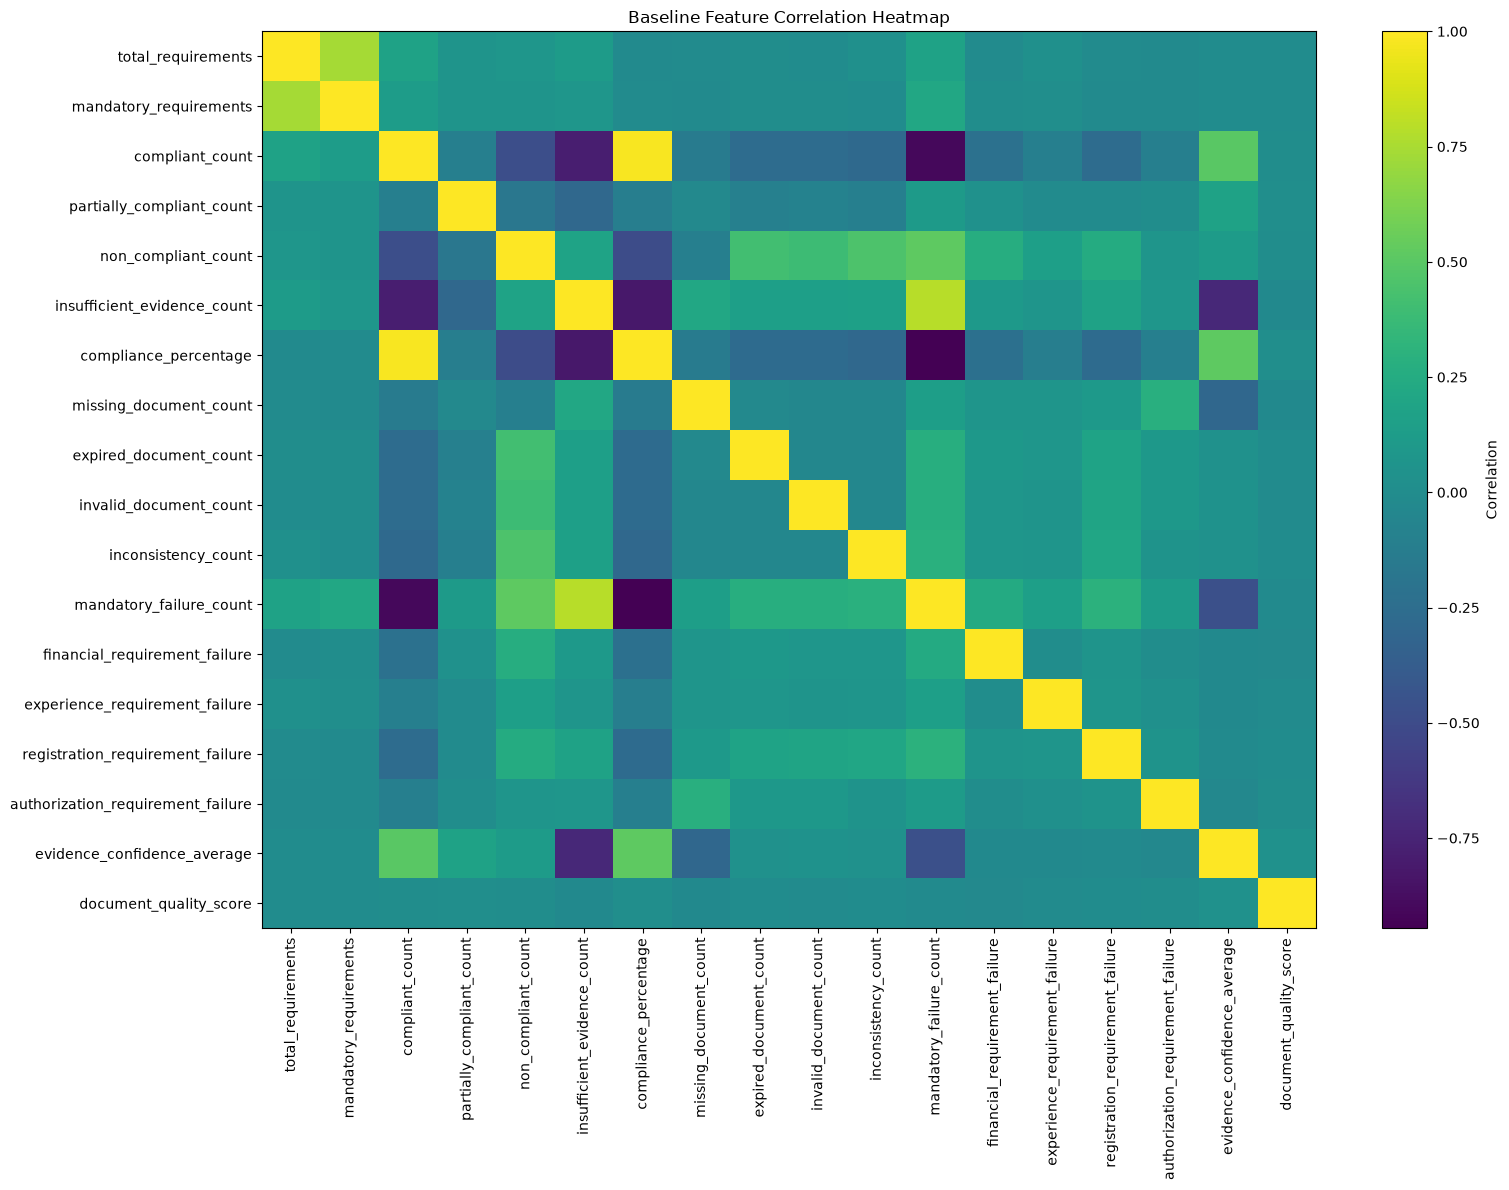

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

correlation_matrix = df[baseline_features].corr()

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(baseline_features)),
    baseline_features,
    rotation=90
)

plt.yticks(
    range(len(baseline_features)),
    baseline_features
)

plt.title("Baseline Feature Correlation Heatmap")
plt.tight_layout()

plt.show()

In [20]:
# Remove identifier columns from the ML feature matrix

X_baseline = df[baseline_features].copy()
X_leakage_controlled = df[leakage_controlled_features].copy()

y = df[target].copy()

print("Baseline X shape:", X_baseline.shape)
print("Leakage-controlled X shape:", X_leakage_controlled.shape)
print("Target shape:", y.shape)

Baseline X shape: (4748, 18)
Leakage-controlled X shape: (4748, 4)
Target shape: (4748,)


In [21]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
X_base_train, X_base_temp, y_train, y_temp = train_test_split(
    X_baseline,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_base_val, X_base_test, y_val, y_test = train_test_split(
    X_base_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Same split indices for leakage-controlled features
X_lc_train = X_leakage_controlled.loc[X_base_train.index]
X_lc_val = X_leakage_controlled.loc[X_base_val.index]
X_lc_test = X_leakage_controlled.loc[X_base_test.index]

print("Baseline:")
print("Train:", X_base_train.shape)
print("Validation:", X_base_val.shape)
print("Test:", X_base_test.shape)

print("\nLeakage-controlled:")
print("Train:", X_lc_train.shape)
print("Validation:", X_lc_val.shape)
print("Test:", X_lc_test.shape)

print("\nTarget:")
print("Train:", y_train.shape)
print("Validation:", y_val.shape)
print("Test:", y_test.shape)

Baseline:
Train: (3323, 18)
Validation: (712, 18)
Test: (713, 18)

Leakage-controlled:
Train: (3323, 4)
Validation: (712, 4)
Test: (713, 4)

Target:
Train: (3323,)
Validation: (712,)
Test: (713,)


In [22]:
# Verify target distribution after train/validation/test split

split_distribution = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True).mul(100),
    "Validation (%)": y_val.value_counts(normalize=True).mul(100),
    "Test (%)": y_test.value_counts(normalize=True).mul(100)
}).round(2)

print("Risk-level distribution across splits:")
print(split_distribution)

Risk-level distribution across splits:
            Train (%)  Validation (%)  Test (%)
risk_level                                     
LOW             39.99           40.03     39.97
MEDIUM          35.00           34.97     35.06
HIGH            25.01           25.00     24.96


In [23]:
# Identify binary and continuous/count features

binary_features = [
    "financial_requirement_failure",
    "experience_requirement_failure",
    "registration_requirement_failure",
    "authorization_requirement_failure"
]

continuous_features = [
    feature for feature in baseline_features
    if feature not in binary_features
]

print("Binary features:", len(binary_features))
print(binary_features)

print("\nContinuous/count features:", len(continuous_features))
print(continuous_features)

Binary features: 4
['financial_requirement_failure', 'experience_requirement_failure', 'registration_requirement_failure', 'authorization_requirement_failure']

Continuous/count features: 14
['total_requirements', 'mandatory_requirements', 'compliant_count', 'partially_compliant_count', 'non_compliant_count', 'insufficient_evidence_count', 'compliance_percentage', 'missing_document_count', 'expired_document_count', 'invalid_document_count', 'inconsistency_count', 'mandatory_failure_count', 'evidence_confidence_average', 'document_quality_score']


In [24]:
# Validate binary feature values

print("Unique values in binary features:\n")

for feature in binary_features:
    print(f"{feature}: {sorted(df[feature].unique().tolist())}")

Unique values in binary features:

financial_requirement_failure: [0, 1]
experience_requirement_failure: [0, 1]
registration_requirement_failure: [0, 1]
authorization_requirement_failure: [0, 1]


In [25]:
from sklearn.preprocessing import StandardScaler

# Create scalers for the continuous/count features
baseline_scaler = StandardScaler()
leakage_controlled_scaler = StandardScaler()

# Fit only on training data
X_base_train_scaled = baseline_scaler.fit_transform(X_base_train)
X_base_val_scaled = baseline_scaler.transform(X_base_val)
X_base_test_scaled = baseline_scaler.transform(X_base_test)

X_lc_train_scaled = leakage_controlled_scaler.fit_transform(X_lc_train)
X_lc_val_scaled = leakage_controlled_scaler.transform(X_lc_val)
X_lc_test_scaled = leakage_controlled_scaler.transform(X_lc_test)

print("Baseline scaled shapes:")
print("Train:", X_base_train_scaled.shape)
print("Validation:", X_base_val_scaled.shape)
print("Test:", X_base_test_scaled.shape)

print("\nLeakage-controlled scaled shapes:")
print("Train:", X_lc_train_scaled.shape)
print("Validation:", X_lc_val_scaled.shape)
print("Test:", X_lc_test_scaled.shape)

Baseline scaled shapes:
Train: (3323, 18)
Validation: (712, 18)
Test: (713, 18)

Leakage-controlled scaled shapes:
Train: (3323, 4)
Validation: (712, 4)
Test: (713, 4)


In [26]:
# Convert scaled arrays back to DataFrames while preserving feature names

X_base_train_scaled_df = pd.DataFrame(
    X_base_train_scaled,
    columns=baseline_features,
    index=X_base_train.index
)

X_base_val_scaled_df = pd.DataFrame(
    X_base_val_scaled,
    columns=baseline_features,
    index=X_base_val.index
)

X_base_test_scaled_df = pd.DataFrame(
    X_base_test_scaled,
    columns=baseline_features,
    index=X_base_test.index
)

X_lc_train_scaled_df = pd.DataFrame(
    X_lc_train_scaled,
    columns=leakage_controlled_features,
    index=X_lc_train.index
)

X_lc_val_scaled_df = pd.DataFrame(
    X_lc_val_scaled,
    columns=leakage_controlled_features,
    index=X_lc_val.index
)

X_lc_test_scaled_df = pd.DataFrame(
    X_lc_test_scaled,
    columns=leakage_controlled_features,
    index=X_lc_test.index
)

print("Baseline scaled DataFrame:", X_base_train_scaled_df.shape)
print("Leakage-controlled scaled DataFrame:", X_lc_train_scaled_df.shape)

Baseline scaled DataFrame: (3323, 18)
Leakage-controlled scaled DataFrame: (3323, 4)


In [27]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Target classes:")
print(label_encoder.classes_)

print("\nEncoded labels:")
print("Train:", sorted(set(y_train_encoded)))
print("Validation:", sorted(set(y_val_encoded)))
print("Test:", sorted(set(y_test_encoded)))

Target classes:
['HIGH' 'LOW' 'MEDIUM']

Encoded labels:
Train: [np.int64(0), np.int64(1), np.int64(2)]
Validation: [np.int64(0), np.int64(1), np.int64(2)]
Test: [np.int64(0), np.int64(1), np.int64(2)]


In [28]:
# Display the exact target encoding mapping

target_mapping = {
    class_name: int(label)
    for label, class_name in enumerate(label_encoder.classes_)
}

print("Risk Level Encoding:")
for risk_level, encoded_value in target_mapping.items():
    print(f"{risk_level} -> {encoded_value}")

Risk Level Encoding:
HIGH -> 0
LOW -> 1
MEDIUM -> 2


In [29]:
# Final ML-ready dataset verification

print("=== Baseline Dataset ===")
print("Train:", X_base_train_scaled_df.shape)
print("Validation:", X_base_val_scaled_df.shape)
print("Test:", X_base_test_scaled_df.shape)

print("\n=== Leakage-Controlled Dataset ===")
print("Train:", X_lc_train_scaled_df.shape)
print("Validation:", X_lc_val_scaled_df.shape)
print("Test:", X_lc_test_scaled_df.shape)

print("\n=== Target Shapes ===")
print("Train:", y_train_encoded.shape)
print("Validation:", y_val_encoded.shape)
print("Test:", y_test_encoded.shape)

print("\n=== Missing Values ===")
print("Baseline Train:", X_base_train_scaled_df.isna().sum().sum())
print("Baseline Validation:", X_base_val_scaled_df.isna().sum().sum())
print("Baseline Test:", X_base_test_scaled_df.isna().sum().sum())

print("\n=== Target Mapping ===")
print(target_mapping)

=== Baseline Dataset ===
Train: (3323, 18)
Validation: (712, 18)
Test: (713, 18)

=== Leakage-Controlled Dataset ===
Train: (3323, 4)
Validation: (712, 4)
Test: (713, 4)

=== Target Shapes ===
Train: (3323,)
Validation: (712,)
Test: (713,)

=== Missing Values ===
Baseline Train: 0
Baseline Validation: 0
Baseline Test: 0

=== Target Mapping ===
{'HIGH': 0, 'LOW': 1, 'MEDIUM': 2}
